In [12]:
%pip install chromadb pypdf openai

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [13]:
from helper_utils import project_embeddings, word_wrap
from pypdf import PdfReader
import os
from openai import OpenAI
from dotenv import load_dotenv
import chromadb
import numpy as np

load_dotenv()


openai_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=openai_key)


reader = PdfReader("docs/microsoft-annual-report.pdf")

pdf_texts = [p.extract_text().strip() for p in reader.pages]

pdf_texts = [text for text in pdf_texts if text]

from langchain.text_splitter import (
    RecursiveCharacterTextSplitter,
    SentenceTransformersTokenTextSplitter
)

character_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""], chunk_size=1000, chunk_overlap=0
)

character_split_texts = character_splitter.split_text("\n\n".join(pdf_texts))

print(word_wrap(character_split_texts[10]))
print(f"\nTotal chunks: {len(character_split_texts)}")




Industry  
Across industries, we are rapidly becoming the partner of choice for any org
anization looking to generate real value from 
AI. In healthcare, for example, we intro
duced the world’s first fully automated clinical documentation application, DAX 
Copilo
t. The application helps physicians reduce documentation time by half, freeing them to 
spend more time face to 
face with patients. And Epic will integrate it directly into i
ts electronic health records system.  
And, in retail, we introduced new tools to help 
companies manage their day-to-day operations and digitize their physical 
stores.  
Mod
ern work  
We are rapidly evolving Microsoft 365 into an AI-first platform that enables
 every individual to amplify their creativity and 
productivity, with both our establis
hed applications like Office and Teams, as well as new apps like Designer, Stream, and 

Loop. Microsoft 365 is designed for today’s digitally connected, distributed workforce
.

Total chunks: 349


In [14]:
pip install sentence-transformers


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [15]:
token_splitter = SentenceTransformersTokenTextSplitter(
    chunk_overlap=0, tokens_per_chunk=256
)

token_split_texts = []
for text in character_split_texts:
    token_split_texts += token_splitter.split_text(text)

# print(word_wrap(token_split_texts[10]))
# print(f"\nTotal chunks: {len(token_split_texts)}")


import chromadb
from chromadb.utils.embedding_functions import SentenceTransformerEmbeddingFunction

embedding_function = SentenceTransformerEmbeddingFunction()

chroma_client = chromadb.Client()
chroma_collection = chroma_client.create_collection(
    "microsoft-collection", embedding_function=embedding_function
)

ids = [str(i) for i in range(len(token_split_texts))]
chroma_collection.add(ids=ids, documents=token_split_texts)
chroma_collection.count()

query = "What was the total revenue for the year?"

results = chroma_collection.query(query_texts=[query], n_results=5)
retrieved_documents = results["documents"][0]














InternalError: Collection [microsoft-collection] already exists

In [ ]:
print(results)

{'ids': [['153', '328', '330', '192', '200']], 'embeddings': None, 'documents': [['general and administrative $ 7, 575 $ 5, 900 28 % as a percent of revenue 4 % 3 % 1ppt 35', 'segment revenue and operating income were as follows during the periods presented : no sales to an individual customer or country other than the united states accounted for more than 10 % of revenue for fiscal years 2023, 2022, or 2021. revenue, classified by the major geographic areas in which our customers were located, was as follows : ( a ) includes billings to oems and certain multinational organizations because of the nature of these businesses and the impracticability of determining the geographic source of the revenue. ( in millions ) year ended june 30, 2023 2022 2021 revenue productivity and business processes $ 69, 274 $ 63, 364 $ 53, 915 intelligent cloud 87, 907 74, 965 59, 728 more personal computing 54, 734 59, 941 54, 445 total $ 211, 915 $ 198, 270 $ 168, 088 operating income productivity and bus

In [16]:
def augment_query_generated(query, model="gpt-3.5-turbo"):
    prompt = """You are a helpful financial research assistant.
    Provide an example answer to the give question, that might be found in a document like an annual report.
    """
    messages = [
        {
            "role": "system",
            "content": prompt,
        },
        {"role": "user", "content": query},
    ]

    response = client.chat.completions.create(
        model=model,
        messages=messages
    )

    content = response.choices[0].message.content
    return content






In [17]:
original_query = "What was the total profit for the year, and how does it compare to the previous year?"
hypothetical_answer = augment_query_generated(original_query)

joint_query = f"{original_query} {hypothetical_answer}"

results = chroma_collection.query(
    query_texts=joint_query,
    n_results=5, include=["documents", "embeddings"]
)




In [18]:
print(results)

{'ids': [['152', '149', '147', '245', '144']], 'embeddings': [array([[ 0.04817101, -0.01345438,  0.01401413, ..., -0.11146735,
        -0.00111627,  0.01070181],
       [ 0.08376013, -0.02007408,  0.00846594, ..., -0.10810196,
        -0.00031927, -0.04082301],
       [ 0.04380205, -0.05092056,  0.01151623, ..., -0.11480366,
         0.02963802, -0.08289432],
       [ 0.03292217, -0.06313017, -0.00804769, ..., -0.16644508,
        -0.11213643,  0.05616956],
       [ 0.00145324, -0.10235541,  0.00681434, ..., -0.120767  ,
         0.02408389, -0.02483282]])], 'documents': [['sales and marketing expenses increased $ 934 million or 4 % driven by 3 points of growth from the nuance and xandr acquisitions and investments in commercial sales, offset in part by a decline in windows advertising. sales and marketing included a favorable foreign currency impact of 2 %. general and administrative general and administrative expenses include payroll, employee benefits, stock - based compensation exp

In [19]:

retrieved_documents = results["documents"][0]
print(retrieved_documents)


['sales and marketing expenses increased $ 934 million or 4 % driven by 3 points of growth from the nuance and xandr acquisitions and investments in commercial sales, offset in part by a decline in windows advertising. sales and marketing included a favorable foreign currency impact of 2 %. general and administrative general and administrative expenses include payroll, employee benefits, stock - based compensation expense, employee severance expense incurred as part of a corporate program, and other headcount - related expenses associated with ( in millions, except percentages ) 2023 2022 percentage change research and development $ 27, 195 $ 24, 512 11 % as a percent of revenue 13 % 12 % 1ppt ( in millions, except percentages ) 2023 2022 percentage change sales and marketing $ 22, 759 $ 21, 825 4 % as a percent of revenue 11 % 11 % 0ppt ( in millions, except percentages ) 2023 2022 percentage change', '• gaming revenue decreased $ 764 million or 5 % driven by declines in xbox hardware

In [20]:
pip install umap-learn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [21]:
import umap
embeddings = chroma_collection.get(include=["embeddings"])["embeddings"]
umap_transform = umap.UMAP(random_state=0, transform_seed=0).fit(embeddings)

projected_dataset_embeddings = project_embeddings(embeddings, umap_transform)

retrieved_embeddings = results["embeddings"][0]
original_query_embedding = embedding_function([original_query])
augmented_query_embedding = embedding_function([joint_query])

projected_original_query_embedding = project_embeddings(
    original_query_embedding, umap_transform
)
projected_augmented_query_embedding = project_embeddings(
    augmented_query_embedding, umap_transform
)

projected_retrieved_embeddings = project_embeddings(
    retrieved_embeddings, umap_transform
)



/Users/quazirazeenjubair/Library/Python/3.9/lib/python/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [22]:
pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 7.8 MB 2.7 MB/s eta 0:00:01
     |████████████████████████████████| 122 kB 9.1 MB/s eta 0:00:01
     |████████████████████████████████| 64 kB 13.7 MB/s eta 0:00:01
     |████████████████████████████████| 249 kB 10.6 MB/s eta 0:00:01
     |████████████████████████████████| 2.9 MB 12.0 MB/s eta 0:00:01
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


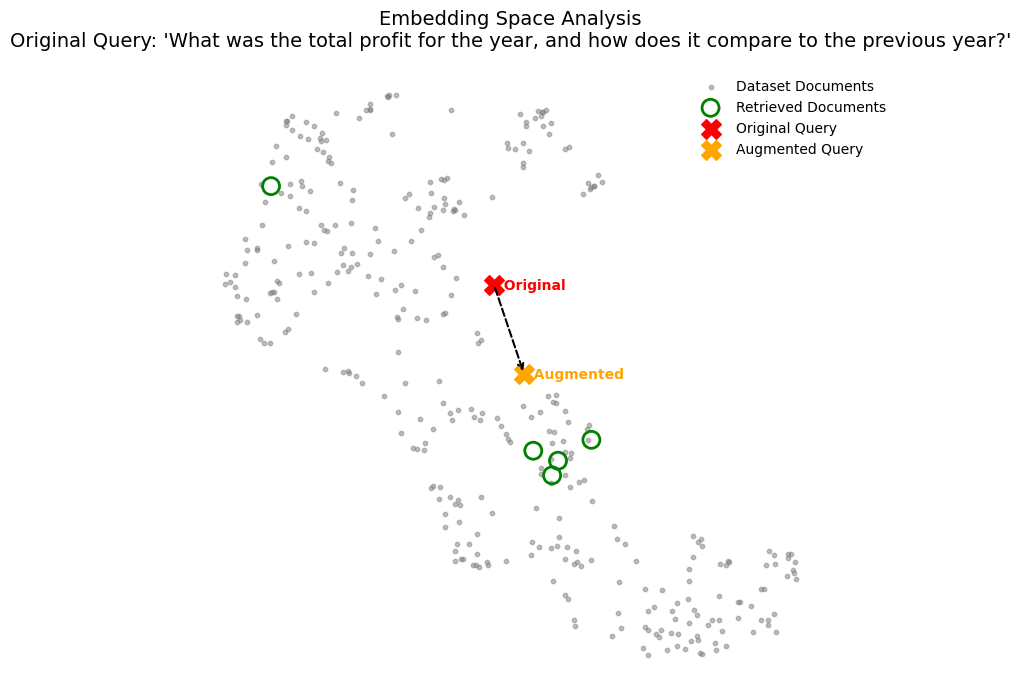

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# 1. Plot the background dataset (gray dots)
plt.scatter(
    projected_dataset_embeddings[:, 0],
    projected_dataset_embeddings[:, 1],
    s=10,
    color="gray",
    alpha=0.5,
    label="Dataset Documents"
)

# 2. Plot the retrieved documents (large green open circles)
plt.scatter(
    projected_retrieved_embeddings[:, 0],
    projected_retrieved_embeddings[:, 1],
    s=150,
    facecolors="none",
    edgecolors="g",
    linewidths=2,
    label="Retrieved Documents"
)

# 3. Plot the original query (Red X)
plt.scatter(
    projected_original_query_embedding[:, 0],
    projected_original_query_embedding[:, 1],
    s=200,
    marker="X",
    color="r",
    label="Original Query"
)

# 4. Plot the augmented query (Orange X)
plt.scatter(
    projected_augmented_query_embedding[:, 0],
    projected_augmented_query_embedding[:, 1],
    s=200,
    marker="X",
    color="orange",
    label="Augmented Query"
)

# --- TEXT & VISUAL ANNOTATIONS ---

# Text label for Original Query
plt.text(
    projected_original_query_embedding[0, 0],
    projected_original_query_embedding[0, 1],
    "  Original",
    color="red",
    fontweight="bold",
    va="center"
)

# Text label for Augmented Query
plt.text(
    projected_augmented_query_embedding[0, 0],
    projected_augmented_query_embedding[0, 1],
    "  Augmented",
    color="orange",
    fontweight="bold",
    va="center"
)

# Arrow showing the query expansion vector shift
plt.annotate(
    "",
    xy=(projected_augmented_query_embedding[0, 0], projected_augmented_query_embedding[0, 1]),
    xytext=(projected_original_query_embedding[0, 0], projected_original_query_embedding[0, 1]),
    arrowprops=dict(arrowstyle="->", color="black", lw=1.5, ls="--")
)

# --- PLOT SETTINGS ---
plt.gca().set_aspect("equal", "datalim")
plt.title(f"Embedding Space Analysis\nOriginal Query: '{original_query}'", fontsize=14, pad=15)
plt.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="none")
plt.axis("off")

plt.show()
